<div style="background: linear-gradient(135deg, #123b5d, #1f6f8b); color: white; padding: 28px; border-radius: 12px;">
  <h1 style="margin: 0;">GBU 2301: Business Statistics</h1>
  <h2 style="margin: 8px 0 18px 0; font-weight: 400;">Week 2: Tabular and Graphical Displays</h2>
  <p style="margin: 0; font-size: 1.05em;">Fall 2026 | Dr. Omer Cayirli | Assistant Professor of Finance</p>
</div>

Required reading: Anderson et al., Statistics for Business and Economics, 15th ed., Chapter 2

---

### Outline

* Summarizing One Variable
    * Categorical Data
    * Quantitative Data
* Summarizing Two Variables
    * Crosstabulations
    * Graphical Displays
* Data Visualization
    * Creating Effective Displays
    * Choosing a Display
    * Data Dashboards

---

### Summarizing Categorical Data

* Frequency Distribution
* Relative Frequency Distribution
* Percent Frequency Distribution
* Bar Chart
* Pie Chart

---

### Pelican Stores

The Pelican Stores data contain 100 customer records and eight variables.

| Variable | Meaning |
|---|---|
| customer | Customer identifier |
| customer_type | Regular or promotional customer |
| items | Number of items purchased |
| net_sales | Net sales in dollars |
| payment_method | Method of payment |
| gender | Recorded customer gender |
| marital_status | Recorded marital status |
| age | Customer age in years |

The data are supplied with Anderson et al. One row represents one recorded customer.

---

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
navy, teal, orange = "#123b5d", "#1f6f8b", "#d8872d"

data_path = Path("../../datasets/PelicanStores.xlsx")
pelican = pd.read_excel(data_path, sheet_name="Data")
pelican = pelican.rename(columns={
    "Customer": "customer",
    "Type of Customer": "customer_type",
    "Items": "items",
    "Net Sales": "net_sales",
    "Method of Payment": "payment_method",
    "Gender": "gender",
    "Marital Status": "marital_status",
    "Age": "age"
})

print(f"Observations: {len(pelican)} | Variables: {pelican.shape[1]}")
display(pelican.head(10))

Observations: 100 | Variables: 8


,customer,customer_type,items,net_sales,payment_method,gender,marital_status,age
0,1,Regular,1,39.50,Discover,Male,Married,32
1,2,Promotional,1,102.40,Proprietary Card,Female,Married,36
2,3,Regular,1,22.50,Proprietary Card,Female,Married,32
3,4,Promotional,5,100.40,Proprietary Card,Female,Married,28
4,5,Regular,2,54.00,MasterCard,Female,Married,34
5,6,Regular,1,44.50,MasterCard,Female,Married,44
6,7,Promotional,2,78.00,Proprietary Card,Female,Married,30
7,8,Regular,1,22.50,Visa,Female,Married,40
8,9,Promotional,2,56.52,Proprietary Card,Female,Married,46
9,10,Regular,1,44.50,Proprietary Card,Female,Married,36


### Frequency Distribution for Categorical Data

A frequency distribution lists the number of observations in each category.

The categories must be:

* Nonoverlapping: an observation is not counted in two categories.
* Collectively exhaustive: every observation belongs to a category.

The sum of the class frequencies must equal the number of observations, n.

When rare categories are combined into an Other category, the rule used to combine them should be stated.

---

### Relative and Percent Frequency Distributions

For a class with frequency f and a data set containing n observations:

$$
\text{Relative frequency}=\frac{f}{n}
$$

$$
\text{Percent frequency}=100\left(\frac{f}{n}\right)
$$

The relative frequencies sum to 1, and the percent frequencies sum to 100 percent.

Counts describe volume. Relative and percent frequencies allow comparisons when group totals differ.

---

In [2]:
payment_summary = (
    pelican["payment_method"]
    .value_counts()
    .rename_axis("payment_method")
    .reset_index(name="frequency")
)
payment_summary["relative_frequency"] = payment_summary["frequency"] / len(pelican)
payment_summary["percent_frequency"] = 100 * payment_summary["relative_frequency"]

display(payment_summary.round({"relative_frequency": 2, "percent_frequency": 1}))
print("Frequency total:", payment_summary["frequency"].sum())
print("Relative-frequency total:", payment_summary["relative_frequency"].sum())

,payment_method,frequency,relative_frequency,percent_frequency
0,Proprietary Card,70,0.70,70.0
1,MasterCard,14,0.14,14.0
2,Visa,10,0.10,10.0
3,Discover,4,0.04,4.0
4,American Express,2,0.02,2.0


Frequency total: 100
Relative-frequency total: 1.0


### Bar Chart

A bar chart represents the frequency, relative frequency, or percent frequency of categorical data.

* Each bar represents a distinct category.
* The bars are separated because adjacent categories do not form a numerical interval.
* Sorting bars can make rankings easier to see.
* A count scale and a percent scale answer different questions when group totals differ.

Because bar length carries the comparison, the numerical axis should generally begin at zero.

---

### Pie Chart

A pie chart represents categories as parts of a whole. The size of each sector is determined by its relative or percent frequency.

The two displays contain the same frequency information, but they do not support comparison equally well.

* Bar lengths share a common baseline and are easier to compare.
* Pie charts become difficult to read when there are many categories or similar shares.
* Three-dimensional effects distort sector sizes without adding information.

A pie chart may communicate a simple composition. A bar chart is generally the stronger default for comparison.

---

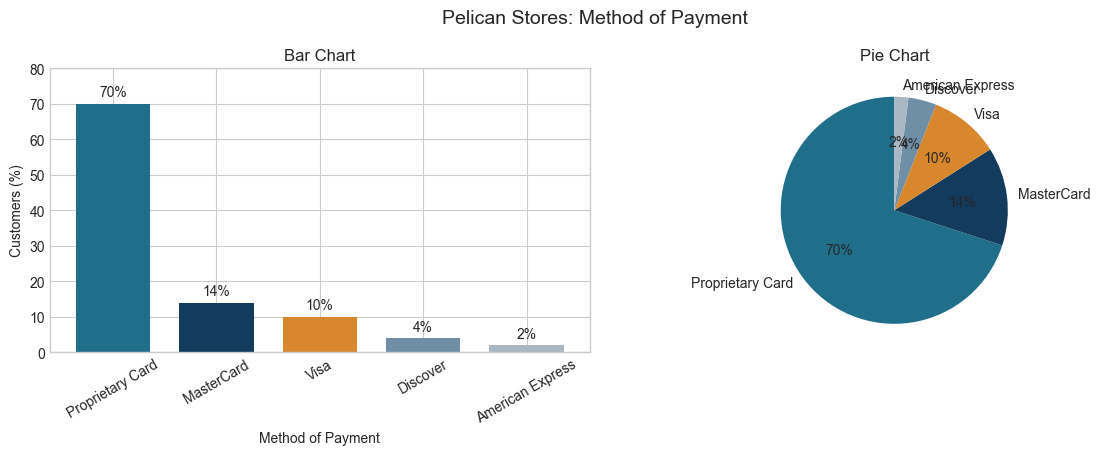

In [3]:
shares = payment_summary.set_index("payment_method")["percent_frequency"]
colors = [teal, navy, orange, "#6f8fa6", "#a8b7c1"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
shares.plot(kind="bar", ax=axes[0], color=colors, width=0.72)
axes[0].set_title("Bar Chart")
axes[0].set_xlabel("Method of Payment")
axes[0].set_ylabel("Customers (%)")
axes[0].set_ylim(0, 80)
axes[0].tick_params(axis="x", rotation=30)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f%%", padding=3)

axes[1].pie(shares, labels=shares.index, autopct="%1.0f%%", startangle=90, colors=colors)
axes[1].set_title("Pie Chart")
fig.suptitle("Pelican Stores: Method of Payment", fontsize=14)
plt.tight_layout()
plt.show()

### Exercise 1

Pelican Stores recorded four Discover customers and two American Express customers in the sample of 100. The finance manager proposes discontinuing both payment methods because their frequencies are small. The proposed report contains only the five frequency counts and a pie chart.

Prepare a recommendation for management. Determine how the payment-method data should be summarized and displayed, whether the two categories should be combined, what the sample supports, and what further evidence is needed before payment options are removed.

---

### Frequency Distribution for Quantitative Data

A quantitative variable may contain many distinct values. Grouping values into nonoverlapping classes reveals concentration and variation that can be difficult to see in the raw rows.

Constructing a grouped frequency distribution requires decisions about:

1. The number of classes
2. The width of the classes
3. The class limits

The classes must cover the observed range, and each observation must belong to exactly one class. Relative and percent frequencies are calculated from the class counts in the same way as for categorical data.

---

### Number of Classes and Class Width

An approximate class width is

$$
\text{Approximate class width}=\frac{\text{largest value}-\text{smallest value}}{\text{number of classes}}
$$

For Pelican Stores net sales:

$$
\frac{287.59-13.23}{6}=45.73
$$

A convenient width of 50 dollars produces six classes. The number of classes and class width are judgment choices. Different choices can be equally defensible.

---

### Class Limits and Class Midpoints

Class limits specify which observations belong to a class. For net sales measured to the nearest cent, one possible set of classes is:

* 0.00 to 49.99
* 50.00 to 99.99
* 100.00 to 149.99
* 150.00 to 199.99
* 200.00 to 249.99
* 250.00 to 299.99

The class midpoint is halfway between the lower and upper class limits. The first midpoint is approximately 25 dollars.

The interval convention must be stated clearly, especially when values can lie on a boundary.

---

In [4]:
sales_bins = np.arange(0, 301, 50)
sales_labels = [
    "0.00 to 49.99", "50.00 to 99.99", "100.00 to 149.99",
    "150.00 to 199.99", "200.00 to 249.99", "250.00 to 299.99"
]
sales_class = pd.cut(
    pelican["net_sales"], bins=sales_bins, labels=sales_labels,
    right=False, include_lowest=True
)
sales_frequency = sales_class.value_counts(sort=False)
sales_summary = pd.DataFrame({
    "frequency": sales_frequency,
    "relative_frequency": sales_frequency / len(pelican),
    "percent_frequency": 100 * sales_frequency / len(pelican),
    "cumulative_frequency": sales_frequency.cumsum(),
    "cumulative_percent": 100 * sales_frequency.cumsum() / len(pelican)
})
sales_summary.index.name = "net_sales_class"
display(sales_summary.round(2))

,frequency,relative_frequency,percent_frequency,cumulative_frequency,cumulative_percent
net_sales_class,,,,,
0.00 to 49.99,39,0.39,39.0,39,39.0
50.00 to 99.99,35,0.35,35.0,74,74.0
100.00 to 149.99,16,0.16,16.0,90,90.0
150.00 to 199.99,6,0.06,6.0,96,96.0
200.00 to 249.99,1,0.01,1.0,97,97.0
250.00 to 299.99,3,0.03,3.0,100,100.0


### Dot Plot

A dot plot places one dot above the horizontal axis for each observation. Repeated values are stacked.

A dot plot preserves the observed values and can reveal:

* Concentrations
* Gaps
* Repeated values
* Unusual observations

Dot plots are most readable for small or moderate data sets and variables with a manageable number of distinct values.

---

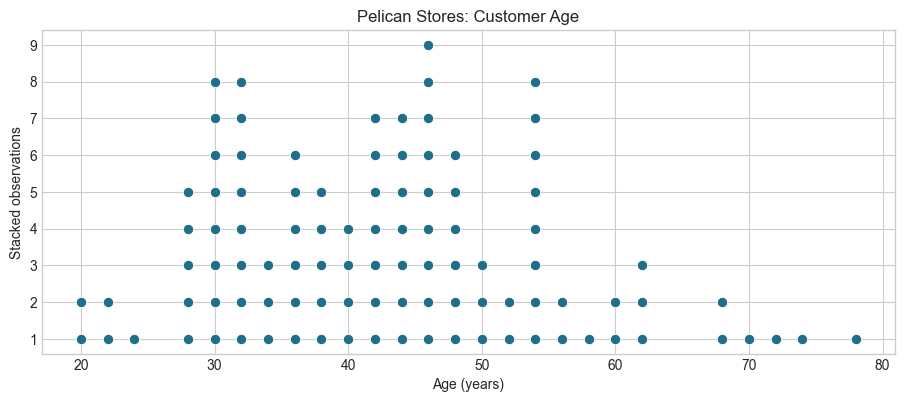

In [5]:
age_counts = pelican["age"].value_counts().sort_index()
dot_x, dot_y = [], []
for age, count in age_counts.items():
    dot_x.extend([age] * count)
    dot_y.extend(range(1, count + 1))

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.scatter(dot_x, dot_y, s=55, color=teal, edgecolor="white", linewidth=0.6)
ax.set_title("Pelican Stores: Customer Age")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Stacked observations")
ax.set_yticks(range(1, max(dot_y) + 1))
plt.show()

### Histogram

A histogram represents the frequency, relative frequency, or percent frequency of quantitative observations within class intervals.

Histogram rectangles touch because adjacent classes represent consecutive numerical intervals. Their order cannot be rearranged.

A bar chart represents separate categories, normally with gaps between bars. The categories may often be reordered without changing their meaning.

The visual similarity between the displays does not make them interchangeable.

---

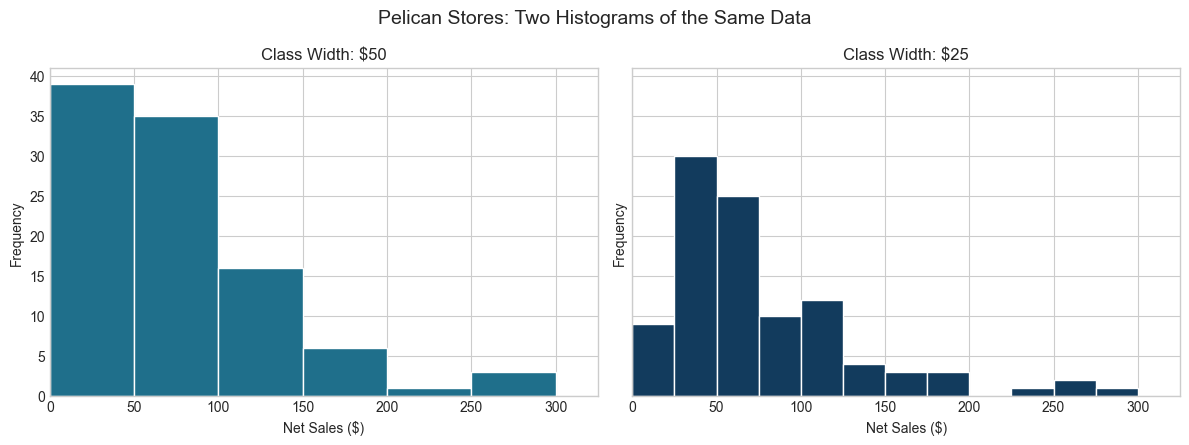

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].hist(pelican["net_sales"], bins=np.arange(0, 301, 50), color=teal, edgecolor="white")
axes[0].set_title("Class Width: $50")
axes[1].hist(pelican["net_sales"], bins=np.arange(0, 326, 25), color=navy, edgecolor="white")
axes[1].set_title("Class Width: $25")
for ax in axes:
    ax.set_xlabel("Net Sales ($)")
    ax.set_ylabel("Frequency")
    ax.set_xlim(0, 325)
fig.suptitle("Pelican Stores: Two Histograms of the Same Data", fontsize=14)
plt.tight_layout()
plt.show()

### Distribution Shape and Class Choice

A distribution may be approximately symmetric, skewed to the left, or skewed to the right. The tail points in the direction of the skew.

Pelican Stores net sales are right-skewed. Most recorded sales are below 100 dollars, while a small number extend beyond 200 dollars.

The broad shape remains visible in both histograms, but the apparent peaks, gaps, and local concentrations change with the class width.

A responsible interpretation distinguishes conclusions that are stable across reasonable class choices from features created by one particular grouping.

---

### Cumulative Distributions

A cumulative distribution adds the classes from the lowest class through a stated upper class limit.

* Cumulative frequency: number of observations less than or equal to the upper limit
* Cumulative relative frequency: corresponding proportion
* Cumulative percent frequency: corresponding percentage

From the grouped Pelican Stores table, 74 customers have net sales below 100 dollars and 96 have net sales below 200 dollars.

Cumulative summaries answer threshold questions. They do not show the frequency inside a single class unless adjacent cumulative values are compared.

---

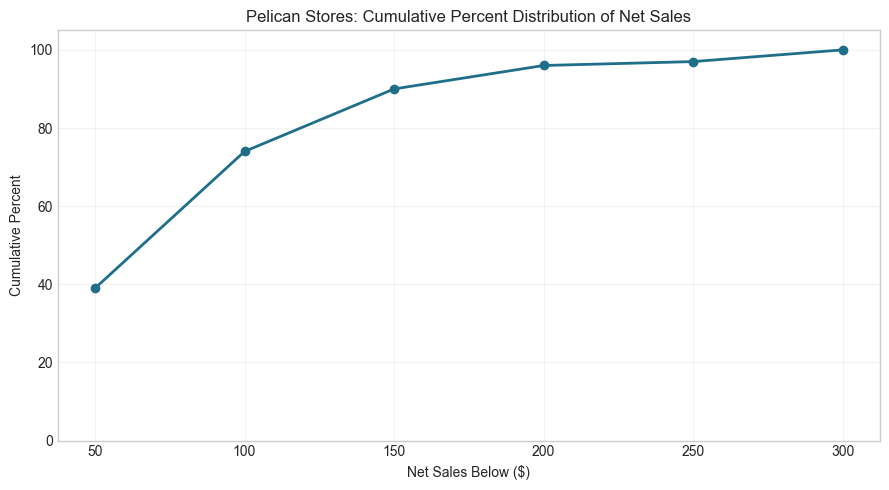

In [7]:
upper_limits = sales_bins[1:]
cumulative_percent = sales_summary["cumulative_percent"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(upper_limits, cumulative_percent, marker="o", color=teal, linewidth=2)
ax.set(
    title="Pelican Stores: Cumulative Percent Distribution of Net Sales",
    xlabel="Net Sales Below ($)",
    ylabel="Cumulative Percent",
    xticks=upper_limits,
    ylim=(0, 105),
)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Stem-and-Leaf Display

A stem-and-leaf display shows both rank order and distribution shape while retaining the observed values. For the ages of the first 30 Pelican Stores customers:

```text
Leaf unit = 1 year
2 | 2 4 8 8
3 | 0 2 2 2 2 4 6 6 6 8
4 | 0 0 0 0 2 2 4 6 6 8 8
5 | 0 4 6
6 | 0
7 | 0
```

The value 4 | 6 represents age 46. A crowded stem may be stretched into separate rows for leaves 0 to 4 and 5 to 9. If the leaf unit is 10, 0.1, or another value, it must be reported.

---

### Exercise 2

Two analysts use the Pelican Stores net-sales data to support a proposed customer segmentation. One uses class widths of 50 dollars and describes a broad low-sales group with a long upper tail. The other uses class widths of 25 dollars and claims that the additional peaks identify several distinct customer groups.

Management asks which interpretation should guide the segmentation decision. Evaluate the two analyses, identify conclusions that are supported regardless of the class width, and recommend what should be examined before the visible groups are treated as genuine customer segments.

---

### Crosstabulation

A crosstabulation summarizes two variables. The classes of one variable form the rows, and the classes of the other form the columns.

The cells show joint frequencies. The margins show the frequency distribution of each variable separately.

Crosstabulations can summarize:

* Two categorical variables
* One categorical variable and a quantitative variable divided into classes
* Two quantitative variables after both are divided into classes

Grouping quantitative values loses detail, so the classes must serve the analytical question.

---

### Row and Column Percentages

Counts alone can be misleading when row or column totals differ. Conditional percentages use a denominator selected by the question.

For a table with customer type in the rows and payment method in the columns:

* Row percentages answer: Within each customer type, how are payment methods distributed?
* Column percentages answer: Within each payment method, how are customer types distributed?

The same cell therefore has two possible conditional percentages. Neither is automatically correct. The comparison determines the denominator.

---

In [8]:
payment_order = payment_summary["payment_method"].tolist()
counts = pd.crosstab(pelican["customer_type"], pelican["payment_method"])[payment_order]
row_percent = 100 * counts.div(counts.sum(axis=1), axis=0)
column_percent = 100 * counts.div(counts.sum(axis=0), axis=1)

print("Frequencies")
display(counts)
print("Row percentages")
display(row_percent.round(1))
print("Column percentages")
display(column_percent.round(1))

Frequencies


payment_method,Proprietary Card,MasterCard,Visa,Discover,American Express
customer_type,,,,,
Promotional,57,7,5,0,1
Regular,13,7,5,4,1


Row percentages


payment_method,Proprietary Card,MasterCard,Visa,Discover,American Express
customer_type,,,,,
Promotional,81.4,10.0,7.1,0.0,1.4
Regular,43.3,23.3,16.7,13.3,3.3


Column percentages


payment_method,Proprietary Card,MasterCard,Visa,Discover,American Express
customer_type,,,,,
Promotional,81.4,50.0,50.0,0.0,50.0
Regular,18.6,50.0,50.0,100.0,50.0


### Simpson's Paradox

An aggregate comparison can reverse after the data are separated into relevant groups. This is Simpson's paradox.

The reversal occurs because the groups can have different baseline outcomes and different representation in the alternatives being compared.

A sound analysis therefore asks:

* Which groups were combined?
* Are their baseline outcomes different?
* Are the alternatives represented in those groups in different proportions?
* Which conditional comparison answers the decision question?

Aggregation is not automatically wrong. Its interpretation depends on the structure hidden inside the total.

---

### Exercise 3

A retailer tests two campaigns. Management observes an overall conversion rate of 26.4 percent for Campaign A and 73.6 percent for Campaign B and plans to move the full budget to Campaign B.

| Customer segment | Campaign A | Campaign B |
|---|---:|---:|
| High intent | 9 conversions from 10 customers | 80 conversions from 100 customers |
| Low intent | 20 conversions from 100 customers | 1 conversion from 10 customers |
| Overall | 29 conversions from 110 customers | 81 conversions from 110 customers |

Prepare a recommendation on the proposed budget decision using the complete table.

---

### Scatter Diagram and Trendline

A scatter diagram displays the relationship between two quantitative variables. Each observation contributes one point.

* The explanatory or organizing variable is usually placed on the horizontal axis.
* The response or outcome of interest is usually placed on the vertical axis.
* The pattern of points can reveal direction, form, strength, clusters, and unusual observations.

A trendline provides an approximation of the overall relationship. It does not make the relationship causal and does not eliminate variation around the line.

---

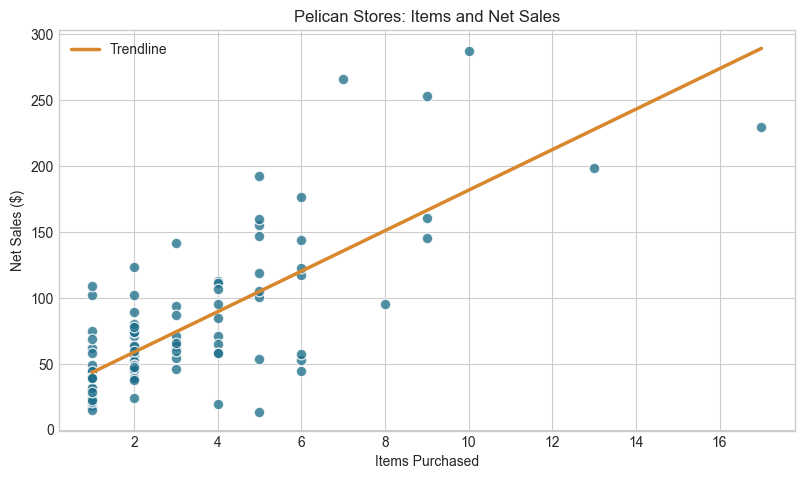

In [9]:
slope, intercept = np.polyfit(pelican["items"], pelican["net_sales"], 1)
trend_x = np.linspace(pelican["items"].min(), pelican["items"].max(), 100)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.scatter(pelican["items"], pelican["net_sales"], s=58, color=teal, alpha=0.78, edgecolor="white")
ax.plot(trend_x, intercept + slope * trend_x, color=orange, linewidth=2.5, label="Trendline")
ax.set_title("Pelican Stores: Items and Net Sales")
ax.set_xlabel("Items Purchased")
ax.set_ylabel("Net Sales ($)")
ax.legend()
plt.show()

### Reading a Scatter Diagram

The Pelican Stores display shows a positive association: customers purchasing more items tend to record higher net sales.

- The relationship is not exact. 
    -   Customers purchasing the same number of items can have different net sales because item prices and discounts differ.
    -   Several observations also lie far from the main concentration.

- A positive pattern does not establish that increasing item count alone will produce the increase represented by the trendline. 
    -   The graph describes association in the recorded data.

- No apparent relationship is also a meaningful result. 
    -   It means that the display does not reveal a systematic pattern, not that the variables are proven unrelated in every population or under every form of relationship.

---

### Side-by-Side and Stacked Bar Charts

Side-by-side bars place category values next to one another. They support direct comparison across groups.

Stacked bars divide each bar into segments. They emphasize how a total is composed.

* Stacked counts preserve differences in group size.
* A 100 percent stacked chart gives every group the same total length and compares composition.
* Internal stacked segments do not share a common baseline and can be difficult to compare.

The choice between counts and percentages depends on whether the question concerns volume or composition.

---

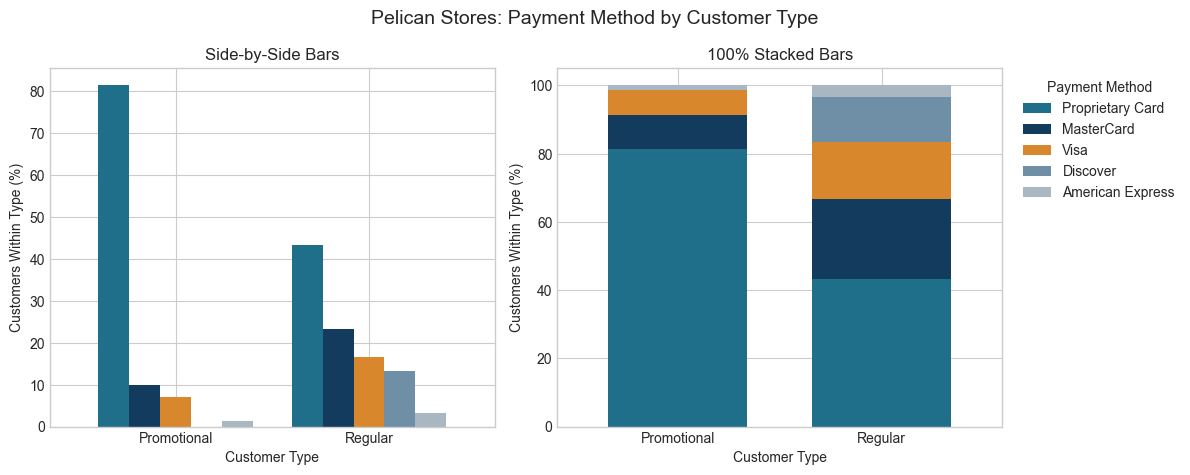

In [10]:
plot_percent = row_percent[payment_order]
plot_colors = [teal, navy, orange, "#6f8fa6", "#a8b7c1"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_percent.plot(kind="bar", ax=axes[0], color=plot_colors, width=0.8)
axes[0].set_title("Side-by-Side Bars")
axes[0].set_ylabel("Customers Within Type (%)")
axes[0].set_xlabel("Customer Type")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend_.remove()

plot_percent.plot(kind="bar", stacked=True, ax=axes[1], color=plot_colors, width=0.68)
axes[1].set_title("100% Stacked Bars")
axes[1].set_ylabel("Customers Within Type (%)")
axes[1].set_xlabel("Customer Type")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Payment Method", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Pelican Stores: Payment Method by Customer Type", fontsize=14)
plt.tight_layout()
plt.show()

### Exercise 4

Pelican Stores management makes two claims:

1. Increasing the number of items in a basket will produce a predictable increase in net sales.

2. Promotional customers are more likely than regular customers to adopt the proprietary card.

Management wants one graphical report to support both claims. Recommend the displays and comparisons that should be used, assess what the observed data support, and identify the parts of the claims that go beyond the evidence.

---

### Creating Effective Graphical Displays

An effective display communicates the relevant information clearly and accurately.

* Use a clear title, axis labels, and units.

* Keep the display simple and avoid unnecessary dimensions or decoration.

* Use distinct colors only when they carry information.

* Place a necessary legend close to the data.

* Report the population, period, denominator, and source when they affect interpretation.

* Use a zero baseline for bar lengths and avoid scales that exaggerate small differences.

A technically correct chart can still mislead through omitted categories, unsuitable denominators, distorted scales, or selective time periods.

---

### Choosing a Graphical Display

| Purpose | Variable structure | Useful displays |
|---|---|---|
| Show a categorical distribution | One categorical variable | Bar chart; pie chart for a simple composition |
| Show a quantitative distribution | One quantitative variable | Dot plot, histogram, stem-and-leaf display |
| Compare categorical distributions | Two categorical variables | Side-by-side or 100 percent stacked bars |
| Show composition and volume | Two categorical variables | Stacked counts with totals reported |
| Show a quantitative relationship | Two quantitative variables | Scatter diagram and, when useful, a trendline |
| Show change through time | Quantitative variable indexed by time | Time-series plot |

The most elaborate display is rarely the most informative. The display should make the intended comparison easy to see.

---

### Data Dashboards

A data dashboard is a coordinated set of visual displays used to monitor the performance of an organization or process.

A useful dashboard identifies:

* The decision maker and the decisions to be supported

* A limited set of relevant key performance indicators

* Current performance, comparison values, and targets

* The required update frequency

* Exceptions that require attention

A page containing several charts is not automatically a dashboard. The displays must work together, use consistent definitions, and inform recurring decisions without overwhelming the user.

---

### Exercise 5

A store director calls a static page based on the 100 Pelican Stores observations a performance dashboard. It contains a three-dimensional pie chart of payment methods, a net-sales histogram with no units, a customer-type bar chart whose numerical axis begins at 60 percent, and a scatter diagram of items and net sales. The page provides no reporting period, targets, comparison values, or update schedule.

Prepare a recommendation on whether the page can support ongoing store management and how it should be redesigned.

---

### What is next?

* Descriptive Statistics II
    
    * Numerical Measures
    
    * Reading(s):
    
        * SBE: Ch. 3

---

### Exercise 6

Northstar Pharmacies ranks 12 branches by the number of customer complaints and plans to sanction the three branches with the highest counts. 
- Monthly transactions range from 8,000 to 55,000 across branches. 

-   Complaints are classified as billing, delivery, product availability, or service. 

-   A customer can submit more than one complaint about the same transaction. 

Audit the data and prepare a recommendation for the operations director.

---

In [11]:
northstar = pd.DataFrame([
    ('N01', 55000, 20, 35, 95, 60),
    ('N02', 49000, 75, 40, 30, 40),
    ('N03', 42000, 32, 60, 38, 40),
    ('N04', 35000, 20, 30, 55, 35),
    ('N05', 31000, 17, 30, 44, 31),
    ('N06', 28000, 18, 26, 39, 29),
    ('N07', 24000, 15, 26, 35, 24),
    ('N08', 21000, 14, 22, 29, 23),
    ('N09', 17000, 13, 18, 24, 19),
    ('N10', 14000, 9, 16, 21, 14),
    ('N11', 10000, 11, 16, 20, 15),
    ('N12', 8000, 14, 20, 25, 21),
], columns=['branch', 'transactions', 'billing', 'delivery', 'availability', 'service'])
complaint_categories = ['billing', 'delivery', 'availability', 'service']
northstar['complaints'] = northstar[complaint_categories].sum(axis=1)
display(northstar[['branch', 'transactions', 'complaints'] + complaint_categories])

,branch,transactions,complaints,billing,delivery,availability,service
0,N01,55000,210,20,35,95,60
1,N02,49000,185,75,40,30,40
2,N03,42000,170,32,60,38,40
3,N04,35000,140,20,30,55,35
4,N05,31000,122,17,30,44,31
5,N06,28000,112,18,26,39,29
6,N07,24000,100,15,26,35,24
7,N08,21000,88,14,22,29,23
8,N09,17000,74,13,18,24,19
9,N10,14000,60,9,16,21,14


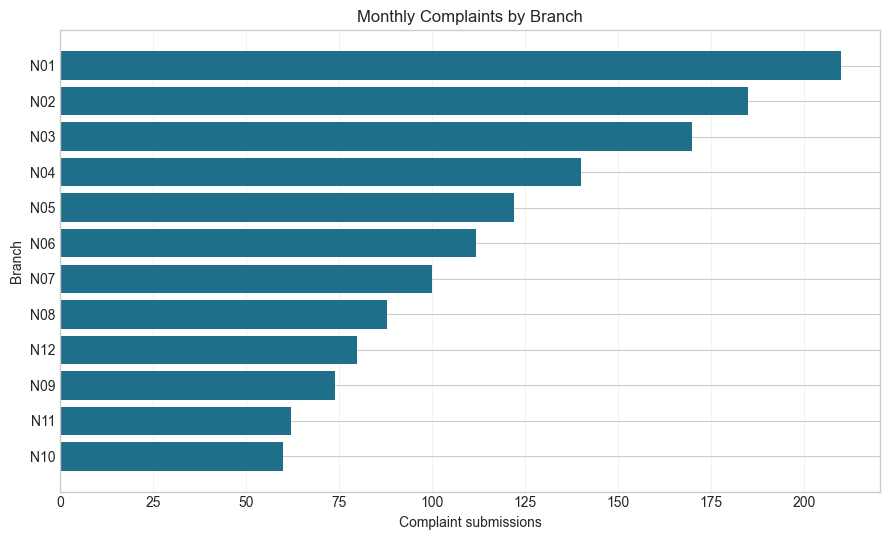

In [12]:
ranked = northstar.sort_values('complaints')
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(ranked['branch'], ranked['complaints'], color='#1f6f8b')
ax.set(xlabel='Complaint submissions', ylabel='Branch', title='Monthly Complaints by Branch')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()

### Exercise 7

A bank is testing two online loan application interfaces. A manager recommends Interface B because more completed applications finished in under five minutes. The table includes completed applications only.

| Completion time (minutes) | Interface A | Interface B |
|---|---:|---:|
| 0 to under 5 | 50 | 80 |
| 5 to under 10 | 90 | 40 |
| 10 to under 15 | 45 | 20 |
| 15 to under 20 | 15 | 60 |

Each interface has 200 completed applications. Abandoned applications are not included.

Assess the manager's recommendation using the full distribution. What should management see before deciding whether to replace A?

---

### Exercise 8

An online retailer reports that a four-week email campaign is succeeding because weekly net sales rose from $42,000 to $53,900. Management wants to expand the campaign. It ran throughout the four weeks.

| Week | Site visits | Purchases | Net sales ($) |
|---|---:|---:|---:|
| 1 | 2,000 | 600 | 42,000 |
| 2 | 2,500 | 750 | 52,500 |
| 3 | 3,000 | 780 | 54,600 |
| 4 | 3,500 | 770 | 53,900 |

Prepare a recommendation. What does the four-week pattern actually show, and what should management monitor before expanding the campaign?

---